# CelebA Processing Steps

Shows every processing option for a CelebA image and where the face landmarks land.
Colored **×** marks = `_CELEBA_REF_128` canonical positions (what we want landmarks to match).
Colored **dots** = actual detected landmarks.

Options compared:
1. **Raw** — 178×218, unmodified
2. **Resize only** (reference approach) — `Resize((128,128))`, no crop, squishes aspect ratio
3. **Current transform** — `Resize(158)` → `RandomCrop(128)` (what our DataLoader currently does)
4. **Center-crop → resize** — square center-crop (178×178) → `Resize(128)`, matches how canonical was measured
5. **Training batch tensor** — what the model actually receives after full transform + normalize

In [1]:
import sys
sys.path.insert(0, '..')

import random
from pathlib import Path

import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision as mp_vision
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch
from PIL import Image
from torchvision.transforms import v2

from kaoanime.utils.align import _ensure_model, _src_pts, _CELEBA_REF_128
from kaoanime.utils.transforms import get_transforms

SEED = 42
N = 8          # images per row
SIZE = 128
ROOT_A = Path('/beta/home/madorskii/datasets/CelebA/img_align_celeba/img_align_celeba')

COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
LABELS = ['L-eye', 'R-eye', 'Nose', 'L-mouth', 'R-mouth']
canonical = _CELEBA_REF_128  # (5,2) in 128×128 space

# ── landmark detector ────────────────────────────────────────────────────────
options = mp_vision.FaceLandmarkerOptions(
    base_options=mp_tasks.BaseOptions(model_asset_path=_ensure_model()),
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
    num_faces=1,
)
landmarker = mp_vision.FaceLandmarker.create_from_options(options)

def detect(img_rgb: np.ndarray):
    """Returns (5,2) landmark array or None."""
    r = landmarker.detect(mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb))
    if not r.face_landmarks:
        return None
    h, w = img_rgb.shape[:2]
    return _src_pts(r.face_landmarks[0], h, w)

# ── load raw images ───────────────────────────────────────────────────────────
exts = {'.jpg', '.jpeg', '.png'}
all_files = [p for p in ROOT_A.iterdir() if p.suffix.lower() in exts]
paths = random.Random(SEED).sample(all_files, N)
print(f'CelebA raw image size: {Image.open(paths[0]).size}')

W0000 00:00:1778700080.740608 1860438 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1778700080.788083 1860438 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1778700080.880661 1860493 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 570.172.08), renderer: NVIDIA A100 80GB PCIe/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1778700080.892594 1860443 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778700080.925770 1860453 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


CelebA raw image size: (178, 218)


## Processing functions

In [2]:
def to_np(pil: Image.Image) -> np.ndarray:
    return np.array(pil.convert('RGB'))

def tensor_to_img(t: torch.Tensor) -> np.ndarray:
    return ((t.permute(1,2,0).numpy() * 0.5 + 0.5) * 255).clip(0,255).astype(np.uint8)

# Option 2: reference approach — just Resize to square
def resize_only(pil: Image.Image, size: int) -> np.ndarray:
    return to_np(pil.resize((size, size), Image.LANCZOS))

# Option 3: current transform — Resize(size+30) then RandomCrop(size)
current_tf = get_transforms('train', image_size=SIZE)
def current_transform(pil: Image.Image) -> np.ndarray:
    # Extract the spatial ops only (skip ToImage/ToDtype/Normalize for display)
    img = v2.Resize(SIZE + 30)(pil)
    img = v2.RandomCrop(SIZE)(img)
    return to_np(img)

# Option 4: center-crop to square → resize (how canonical was measured)
def center_crop_resize(pil: Image.Image, size: int) -> np.ndarray:
    w, h = pil.size
    s = min(w, h)
    pil = pil.crop(((w-s)//2, (h-s)//2, (w+s)//2, (h+s)//2))
    return to_np(pil.resize((size, size), Image.LANCZOS))

# Option 5: full training transform tensor
def full_transform_tensor(pil: Image.Image) -> np.ndarray:
    return tensor_to_img(current_tf(pil))

## Grid: all processing options

Each **column** = one image.  
Each **row** = one processing option.  
**×** = canonical target position.  **●** = detected landmark.

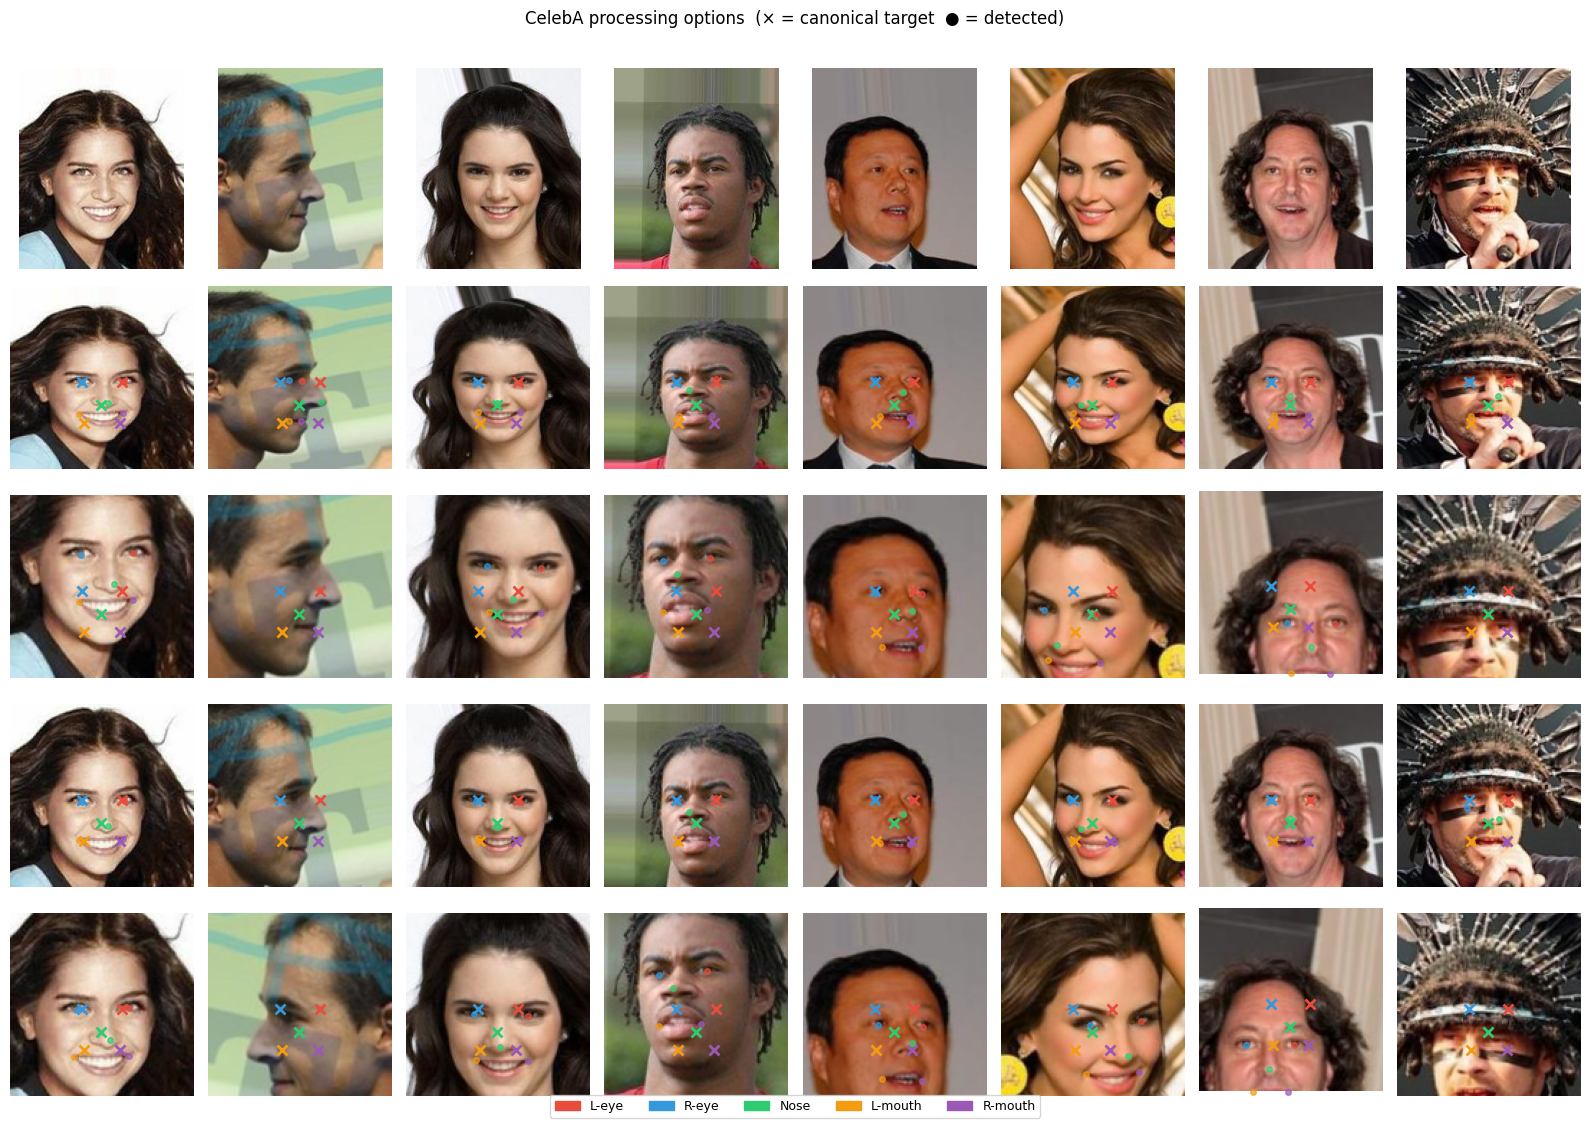

In [3]:
raws = [Image.open(p).convert('RGB') for p in paths]

rows = [
    ('1. Raw (178×218)',             [to_np(img) for img in raws],                  False),
    ('2. Resize only — reference',   [resize_only(img, SIZE) for img in raws],      True),
    ('3. Current (Resize+RndCrop)',   [current_transform(img) for img in raws],      True),
    ('4. CenterCrop → Resize',        [center_crop_resize(img, SIZE) for img in raws], True),
    ('5. Full train transform',       [full_transform_tensor(img) for img in raws],  True),
]

n_rows = len(rows)
fig, axes = plt.subplots(n_rows, N, figsize=(N * 2, n_rows * 2.2))

for r, (label, imgs, overlay) in enumerate(rows):
    axes[r, 0].set_ylabel(label, fontsize=8, rotation=0, labelpad=120, va='center')
    for c, img in enumerate(imgs):
        ax = axes[r, c]
        ax.imshow(img)
        if overlay and img.shape[0] == SIZE:
            # canonical crosses
            for (x, y), col in zip(canonical, COLORS):
                ax.plot(x, y, 'x', color=col, markersize=7, markeredgewidth=2)
            # detected landmarks
            pts = detect(img)
            if pts is not None:
                for (x, y), col in zip(pts, COLORS):
                    ax.plot(x, y, 'o', color=col, markersize=4, alpha=0.7)
        ax.axis('off')

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, LABELS)]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=9)
plt.suptitle('CelebA processing options  (× = canonical target  ● = detected)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Landmark error by option

Mean pixel distance between detected landmarks and canonical positions, over all sampled images.  
Lower = better alignment.

In [ ]:
def mean_landmark_error(imgs):
    errors = []
    for img in imgs:
        if img.shape[0] != SIZE:
            continue
        pts = detect(img)
        if pts is not None:
            errors.append(np.mean(np.linalg.norm(pts - canonical, axis=1)))
    return np.mean(errors) if errors else float('nan'), len(errors)

print(f"{'Option':<35} {'Mean px error':>14}  {'n detected':>10}")
print('-' * 65)
for label, imgs, overlay in rows[1:]:  # skip raw (wrong size)
    err, n = mean_landmark_error(imgs)
    print(f"{label:<35} {err:>14.2f}  {n:>10}")

In [ ]:
landmarker.close()